# Theta-e extra plots

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import sys
import os
from datetime import datetime

from pathlib import Path
import glob
import logging
import dask
import calendar
import iris
from scipy import special
from scipy.interpolate import griddata
from scipy.interpolate import RegularGridInterpolator
import scipy.special
from scipy.stats import mannwhitneyu
from scipy.stats import gaussian_kde
from math import sin, cos, sqrt, atan2, radians, asin
from typing import TypedDict, Optional
import functools

#plotting libraries
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.cm as cm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, TwoSlopeNorm, BoundaryNorm, Normalize
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
import matplotlib.path as mpath
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature

# import functions
sys.path.append(os.path.join(r"/home/563/ac9768/PhD")) 
sys.path.append(os.path.join(r"/home/563/ac9768/PhD/Plotting_scripts")) 
from Plotting_scripts import get_subplot_axes, plot_data_on_axes, plot_violins_seasons, plot_violins_regions
from Plotting_scripts import latitude_weighting, time_weighting
from Plotting_scripts import plot_polar_ndjf_plots, plot_polar_single
from Plotting_scripts import monthly_flux_to_TgS
from Plotting_scripts import get_grid_size

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2    
# %reload_ext autoreload

In [2]:
from dask_setup import setup_dask_client 
from dask_setup import recommend_chunks
client, cluster, dask_tmp = setup_dask_client(mode="interactive", workload_type="auto")
warnings.simplefilter(action='ignore', category=FutureWarning)

INFO     [client] Interactive cluster mode — using already-allocated nodes
INFO     [multinode] Interactive cluster: single node, using LocalCluster (node=gadi-cpu-bdw-0616.gadi.nci.org.au)
INFO     [client] Starting Dask client setup (workload_type=auto | environment=jupyter)
INFO     [resources] Resources detected via PBS (total_cores=28 | total_mem_gib=252.0)
INFO     [client] workload_type='auto' resolved via dataset inspection (workload_type=mixed)


INFO     [client] Temp/spill dir: /jobfs/169801703.gadi-pbs/dask-1806376
INFO     [client] Workers: 14 | threads/worker: 2 | processes: True
INFO     [client] Mem: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
INFO     [client] Compression: spill=auto | comm=False
INFO     [client] Dask client ready


[setup_dask_client] Configuration summary
temp/spill dir: /jobfs/169801703.gadi-pbs/dask-1806376
Workers: 14 | threads/worker: 2 | processes: True
Memory: total ~252.0 GiB | usable ~202.0 GiB | per-worker ~14.4 GiB
Compression: spill=auto | comm=False


# Open BARRA-R2 dataset

In [3]:
def list_barra_paths(var: str):
    """Create list of file paths for the BARRA-R2 variable.
    Using a base path, once the variable is chosen all file paths within the years and months are returned as a list.

    Args:
        var (str): String of radar ID number; towns = 73, cairns = "19", willis island = "41"
        temp_dir (str): Directory to store .nc files, default = "/scratch/v46/ac9768/radar_grndref/"
    Returns:
        list: List of extracted .nc file path strings
    """
    base = "/g/data/ob53/BARRA2/output/reanalysis/AUS-11/BOM/ERA5/historical/hres/BARRA-R2/v1/1hr/"+var+"/latest/"
    # analysis years
    year = np.arange(1979,2025,1)
    # year  = ['2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']
    # analysis months
    month = ['01','02','03','04']
    list = sorted(
        f
        for y in year
        for m in month
        for f in glob.glob(base+var+f"_AUS-11_ERA5_historical_hres_BOM_BARRA-R2_v1_1hr_{y}{m}-{y}{m}.nc")
    )

    if not list:
        raise FileNotFoundError("No files found — check the path.")
        
    list.sort()
    return list

In [4]:
CAPE_fps = list_barra_paths('CAPE')

In [5]:
def preprocess(ds):
    return (
        ds['CAPE']
        .sel(lat=slice(-21.5,-14),lon=slice(143,152))
    )

In [6]:
CAPE = xr.open_mfdataset(CAPE_fps,preprocess=preprocess,engine='h5netcdf',parallel=True)

In [ ]:
# CAPE_subset.plot(rasterized=True)

# Define wind regimes 1979-2024

In [7]:
# barra_towns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_towns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2024-05-01T00:00:00.000000000'))
barra_cairns = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_cairns.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2024-05-01T00:00:00.000000000'))
# barra_willis = xr.open_dataset("/g/data/q90/ac9768/GBR/barra-2/barra-2_850hPa-winds_willis.nc", engine="h5netcdf",chunks="auto").sel(time=slice('1979-01-01T00:00:00.000000000','2024-05-01T00:00:00.000000000'))

In [8]:
def utc_to_lst_shift(ds, longitude_center: float):
    """
    Shift xarray data from UTC to Local Solar Time by offsetting the 
    time coordinate. Adds the LST offset to time labels directly —
    does NOT roll/wrap data values.

    Args:
        ds:               xarray Dataset or DataArray with a 'time' dimension.
        longitude_center: Representative longitude of the region (decimal degrees).

    Returns:
        Dataset/DataArray with time coordinate relabelled to LST.
    """
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    ds_lst = ds.assign_coords(time=ds.time + offset)
    return ds_lst

In [9]:
def wind_times(barra_regime_ds: xr.Dataset, longitude_center: float):
    """
    Classify wind direction at LST solar noon (hour=12), then assign
    all hours of that day to the same wind regime.

    Args:
        barra_regime_ds:  xarray Dataset with 'wind_dir' and 'time' dimension.
        longitude_center: Representative longitude for LST conversion.

    Returns:
        ne, se, sw, nw: arrays of datetime64 timestamps (all hours) 
                        belonging to each wind regime day.
    """
    # 1. Shift full dataset to LST
    ds_lst = utc_to_lst_shift(barra_regime_ds, longitude_center)

    # 2. Extract wind_dir and compute (needed for boolean indexing)
    winds = ds_lst.wind_dir.compute()

    # 3. Select only solar noon (LST hour=12) for regime classification
    winds_noon = winds.sel(time=winds.time.dt.hour == 12)

    # 4. Classify noon wind direction → get dates (not full timestamps)
    ne_dates = winds_noon.time.values[(winds_noon.values >= 0)   & (winds_noon.values <= 90)]
    se_dates = winds_noon.time.values[(winds_noon.values > 90)   & (winds_noon.values <= 180)]
    sw_dates = winds_noon.time.values[(winds_noon.values > 180)  & (winds_noon.values <= 270)]
    nw_dates = winds_noon.time.values[(winds_noon.values > 270)  & (winds_noon.values <= 360)]

    # 5. Convert noon timestamps → date-only for day matching
    def noon_to_all_hours(regime_noon_times):
        """Given noon timestamps, return all LST timestamps on those days."""
        regime_dates = set(
            pd.Timestamp(t).date() for t in regime_noon_times
        )
        all_times = pd.DatetimeIndex(winds.time.values)
        mask = all_times.normalize().map(lambda d: d.date() in regime_dates)
        return winds.time.values[mask]

    ne_lst = noon_to_all_hours(ne_dates)
    se_lst = noon_to_all_hours(se_dates)
    sw_lst = noon_to_all_hours(sw_dates)
    nw_lst = noon_to_all_hours(nw_dates)

    # 6. Convert LST timestamps back to UTC by subtracting the offset
    offset_hours = round(longitude_center * 4 / 60)
    offset = pd.Timedelta(hours=offset_hours)

    # Shift only the time coordinate labels, data values stay aligned
    # ds_lst = ds.assign_coords(time=ds.time + offset)

    
    # offset_hours = round(longitude_center * 4 / 60)
    # offset = np.timedelta64(offset_hours, 'h')

    ne = ne_lst - offset
    se = se_lst - offset
    sw = sw_lst - offset
    nw = nw_lst - offset

    return ne, se, sw, nw


# --- Usage ---
lon_towns  = (145.12054 + 147.9812)  / 2  # ≈ 146.55°E
lon_cairns = (144.27374 + 147.09222) / 2  # ≈ 145.68°E
lon_willis = (148.55927 + 151.36993) / 2

In [10]:
# ne_towns,  se_towns,  sw_towns,  nw_towns  = wind_times(barra_towns,  lon_towns)
ne_cairns, se_cairns, sw_cairns, nw_cairns = wind_times(barra_cairns, lon_cairns)
# ne_willis, se_willis, sw_willis, nw_willis = wind_times(barra_willis, lon_willis)

# Compute variable under wind regimes

In [11]:
regimes = {'ne': ne_cairns, 
           'se': se_cairns,
           'sw': sw_cairns,
           'nw': nw_cairns,
          }
results = {}
for regime, times in regimes.items():
    results[regime] = CAPE.sel(time=times).mean('time')

In [ ]:
# Save results to NetCDF files
# for regime in ['nw', 'ne', 'sw', 'se']:
#     results[regime].to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/CAPE_{regime}_regime_barra-cairns_1979-2024.nc')

# results['se'].to_netcdf(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/CAPE_se_regime_barra-cairns_1979-2024.nc')

# Plot

In [11]:
# load data from saved nc files
site = 'towns'
var = 'CAPE'

results = {}
for regime in ['nw', 'ne', 'sw', 'se']: 
    results[regime] = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/{var}/{var}_{regime}_regime_{site}_1979-2024_pbs.nc')
    # results[regime] = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/{var}/{var}_{regime}_regime_barra-{site}_2012-2022.nc')
    

In [12]:
site_config = {
    'cairns': {
        'lon': 145.683, 'lat': -16.817,
        'range_deg': 1.358,
        'color': 'gold',
        'label': 'Cairns radar range',
    },
    'towns': {
        'lon': 146.5509, 'lat': -19.4198,
        'range_deg': 1.358,
        'color': 'gold',
        'label': 'Townsville radar range',
    },
    'willis': {
        'lon': 149.9646, 'lat': -16.2874,
        'range_deg': 1.358,
        'color': 'darkblue',
        'label': 'Willis Island radar range',
    },
}

cfg = site_config[site]

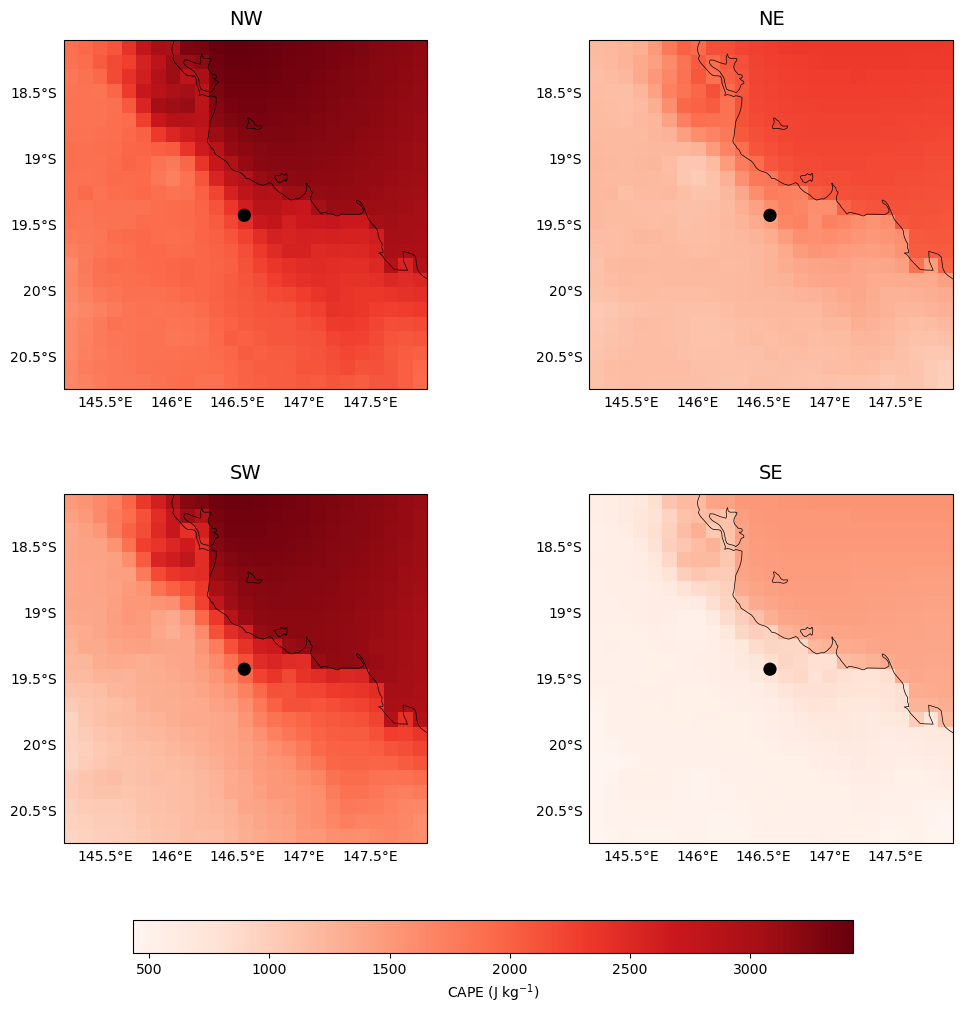

In [13]:
cbar_label = 'CAPE (J kg$^{-1}$)'

# Create figure with 4 subplots + space for colorbar
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, bottom=0.15)
axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) for i in range(2) for j in range(2)]

regime_names = ['NW', 'NE', 'SW', 'SE']
regimes = ['nw', 'ne', 'sw', 'se']

for regime in results:
    results[regime] = results[regime].sel(
        lat=slice(cfg['lat'] - cfg['range_deg'], cfg['lat'] + cfg['range_deg']),
        lon=slice(cfg['lon'] - cfg['range_deg'], cfg['lon'] + cfg['range_deg'])
    )

# Get global min/max for consistent colorbar scaling
vmin = min([results[r][var].min().values for r in regimes])
vmax = max([results[r][var].max().values for r in regimes])
    
for idx, (regime, name) in enumerate(zip(regimes, regime_names)):
    ax = axes[idx]
    
    # Plot
    im = results[regime][var].plot(
        ax=ax,
        cmap='Reds',#'RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # Remove ticks on right and top
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Add coastlines
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    
    ax.set_title(f'{name}', fontsize=14, y=1.02)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    gl = ax.gridlines(draw_labels=True, alpha=0)
    gl.top_labels = False
    gl.right_labels = False

    # add radar plot loc details
    # circle = mpatches.Circle(
    #     (cfg['lon'], cfg['lat']), cfg['range_deg'],
    #     alpha=0.6, fill=False, ec=cfg['color'], lw=3, label=cfg['label']
    # )
    # ax.add_patch(circle)

    circle_center = mpatches.Circle(
        (cfg['lon'], cfg['lat']), 0.05,
        alpha=1, fc='black', zorder=4, label='Radar location'
    )
    ax.add_patch(circle_center)

# Add colorbar below plots
cax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
fig.colorbar(im, cax=cax, orientation='horizontal', label=cbar_label)

plt.savefig(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/{var}_regime_{site}_1979-2024.png', dpi=300, bbox_inches='tight')
plt.show()

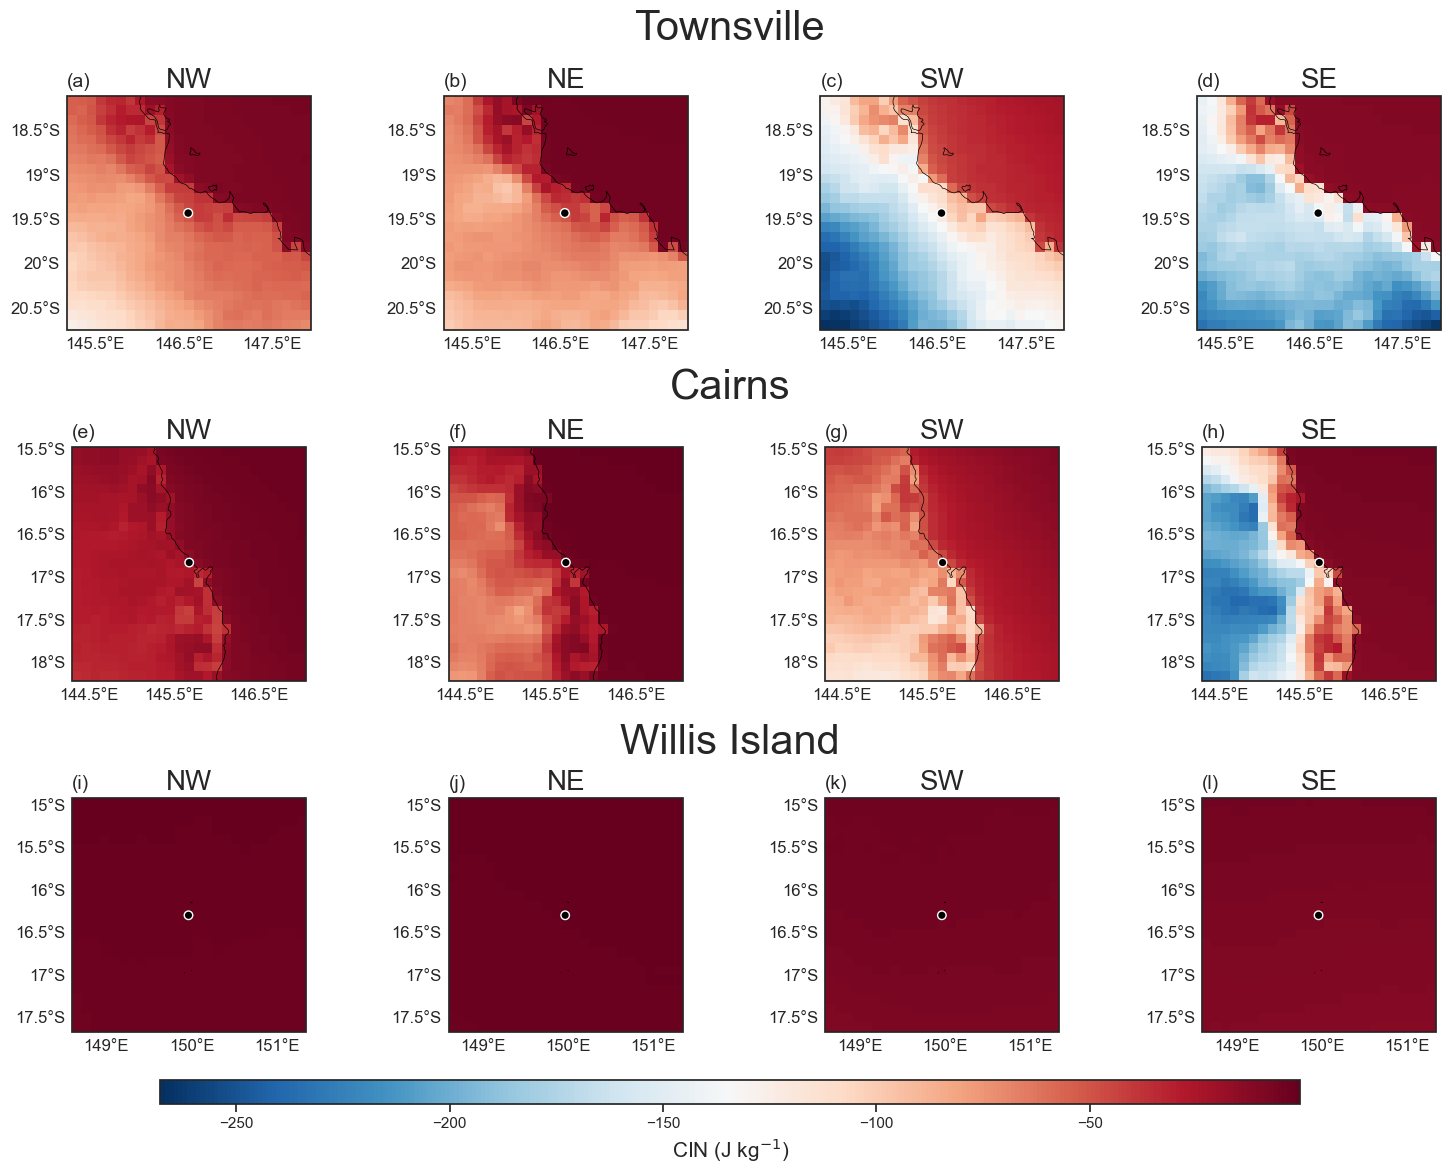

In [5]:
import string
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import numpy as np
import seaborn as sns

sns.set_theme(style="ticks")

sites = ['towns', 'cairns', 'willis']
site_labels = ['Townsville', 'Cairns', 'Willis Island']
regimes = ['nw', 'ne', 'sw', 'se']
regime_names = ['NW', 'NE', 'SW', 'SE']
var = 'CIN'
cbar_label = 'CIN (J kg$^{-1}$)'
labels = list(string.ascii_lowercase)

site_config = {
    'cairns': {'lon': 145.683,  'lat': -16.817,  'range_deg': 1.358, 'color': 'gold',     'label': 'Cairns radar range'},
    'towns':  {'lon': 146.5509, 'lat': -19.4198, 'range_deg': 1.358, 'color': 'gold',     'label': 'Townsville radar range'},
    'willis': {'lon': 149.9646, 'lat': -16.2874, 'range_deg': 1.358, 'color': 'darkblue', 'label': 'Willis Island radar range'},
}

# Load all results
all_results = {}
for site in sites:
    all_results[site] = {}
    for regime in regimes:
        all_results[site][regime] = xr.open_dataset(
            f'/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/theta-e_extras/{var}/{var}_{regime}_regime_{site}_1979-2024_pbs.nc'
        )

# Apply spatial selection per site, then get global vmin/vmax
for site in sites:
    cfg = site_config[site]
    for regime in regimes:
        all_results[site][regime] = all_results[site][regime].sel(
            lat=slice(cfg['lat'] - cfg['range_deg'], cfg['lat'] + cfg['range_deg']),
            lon=slice(cfg['lon'] - cfg['range_deg'], cfg['lon'] + cfg['range_deg'])
        )

vmin = min(all_results[site][r][var].min().values for site in sites for r in regimes)
vmax = max(all_results[site][r][var].max().values for site in sites for r in regimes)

# Build figure: 3 rows x 4 cols, map projections
fig = plt.figure(figsize=(19, 12))
gs = fig.add_gridspec(3, 4, hspace=0.5, wspace=0.1, bottom=0.1)

for row_idx, (site, site_label) in enumerate(zip(sites, site_labels)):
    cfg = site_config[site]
    label_start = row_idx * 4

    for col_idx, (regime, name) in enumerate(zip(regimes, regime_names)):
        ax = fig.add_subplot(gs[row_idx, col_idx], projection=ccrs.PlateCarree())

        im = all_results[site][regime][var].plot(
            ax=ax,
            cmap='RdBu_r',
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False,
            transform=ccrs.PlateCarree()
        )

        ax.coastlines(resolution='10m', linewidth=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

        # Gridlines
        gl = ax.gridlines(draw_labels=True, alpha=0)
        gl.top_labels = False
        gl.right_labels = False

        # Regime title on top row only
        if row_idx == 0:
            ax.set_title(name, fontsize=20, pad=6)

        ax.set_xlabel('Longitude' if row_idx == 2 else '')
        ax.set_ylabel('Latitude'  if col_idx == 0 else '')

        # Radar centre dot
        circle_center = mpatches.Circle(
            (cfg['lon'], cfg['lat']), 0.05,
            alpha=1, fc='black', zorder=4, label='Radar location'
        )
        ax.add_patch(circle_center)

        # Panel label (a), (b), ...
        ax.text(0.00, 1.02, f'({labels[label_start + col_idx]})',
                transform=ax.transAxes, fontsize=14, va='bottom', ha='left')
        ax.set_title(name, fontsize=20, pad=6)

    # Site label to the left of each row
    # fig.text(
    #     0.07,
    #     1 - (row_idx + 0.5) / 3,
    #     site_label,
    #     ha='center', va='center',
    #     fontsize=18, rotation=90
    # )
y_positions = [0.92, 0.62, 0.325]  # tune to match your hspace
for site_label, y in zip(site_labels, y_positions):
    fig.text(0.5, y, site_label, ha='center', va='bottom', fontsize=30)

# Shared horizontal colorbar
cax = fig.add_axes([0.2, 0.04, 0.6, 0.02])
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap='RdBu_r'),
             cax=cax, orientation='horizontal').set_label(cbar_label, fontsize=15)

plt.draw()
fig.savefig(
    f'/home/563/ac9768/GBR/scripts/Chapman_etal_2026preprint/theta-e_extras/{var}/{var}_windregimes_allsites.png',
    bbox_inches='tight', dpi=300
)
plt.show()

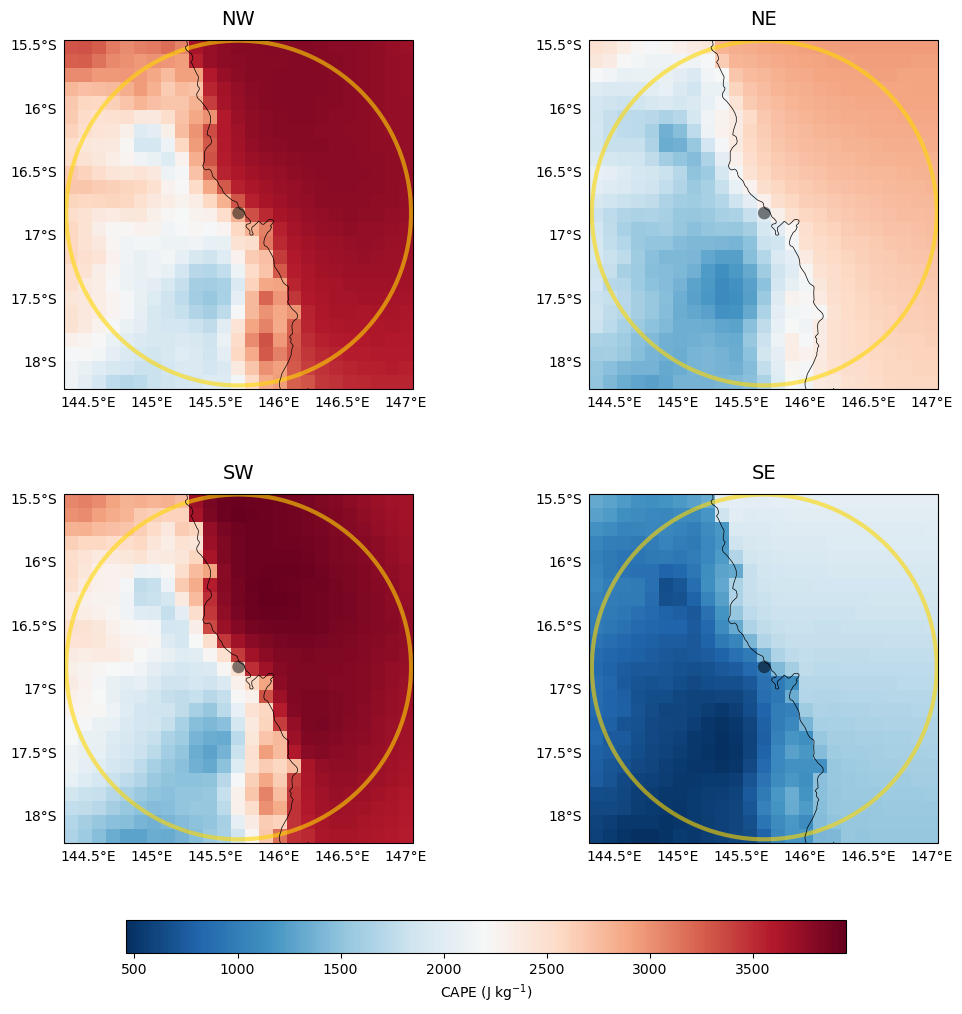

In [18]:
results = {}
for regime in ['nw', 'ne', 'sw', 'se']:
    results[regime] = xr.open_dataset(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/CAPE_{regime}_regime_barra-cairns_1979-2024.nc')
    
# Cairns radar location and range
cairns_lon, cairns_lat = 145.683, -16.817
radar_range_deg = 1.358  # degrees

# Subset data to Cairns radar range
for regime in results:
    results[regime] = results[regime].sel(
        lat=slice(cairns_lat - radar_range_deg, cairns_lat + radar_range_deg),
        lon=slice(cairns_lon - radar_range_deg, cairns_lon + radar_range_deg)
    )

# Create figure with 4 subplots + space for colorbar
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, bottom=0.15)
axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) for i in range(2) for j in range(2)]
regime_names = ['NW', 'NE', 'SW', 'SE']
regimes = ['nw', 'ne', 'sw', 'se']

# Get global min/max for consistent colorbar scaling
vmin = min([results[r].CAPE.min().values for r in regimes])
vmax = max([results[r].CAPE.max().values for r in regimes])

for idx, (regime, name) in enumerate(zip(regimes, regime_names)):
    ax = axes[idx]
    
    # Plot
    im = results[regime].CAPE.plot(
        ax=ax,
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    # Remove ticks on right and top
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    
    # Add coastlines
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    
    ax.set_title(f'{name}', fontsize=14, y=1.02)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    gl = ax.gridlines(draw_labels=True, alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    
    # Add Cairns radar circle boundary
    circle_C = mpatches.Circle((cairns_lon, cairns_lat), radar_range_deg, 
                               alpha=0.6, fill=False, ec='gold', lw=3, label='Cairns radar range')
    ax.add_patch(circle_C)
    
    # Add radar center
    circle_C_center = mpatches.Circle((cairns_lon, cairns_lat), 0.05, 
                                       alpha=0.5, fc="black", zorder=4, label='Radar location')
    ax.add_patch(circle_C_center)

# Add colorbar below plots
cax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
fig.colorbar(im, cax=cax, orientation='horizontal', label='CAPE (J kg$^{-1}$)')

plt.savefig('/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/CAPE_regime_cairns_1979-2024.png', dpi=300, bbox_inches='tight')
plt.show()

# plot all sites (based on one sites wind regime

In [ ]:
site = 'towns'
var = 'CAPE'
cbar_label = 'CAPE (J kg$^{-1}$)'
# Create figure with 4 subplots + space for colorbar
fig = plt.figure(figsize=(12, 11))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3, bottom=0.15)
axes = [fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree()) for i in range(2) for j in range(2)]
regime_names = ['NW', 'NE', 'SW', 'SE']
regimes = ['nw', 'ne', 'sw', 'se']
# Get global min/max for consistent colorbar scaling
vmin = min([results[r][var].min().values for r in regimes])
vmax = max([results[r][var].max().values for r in regimes])
for idx, (regime, name) in enumerate(zip(regimes, regime_names)):
    ax = axes[idx]

    # Plot
    im = results[regime][var].plot(
        ax=ax,
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )
    # Remove ticks on right and top
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')

    # Add coastlines
    ax.coastlines(resolution='10m', linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)

    ax.set_title(f'{name}', fontsize=14, y=1.02)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    gl = ax.gridlines(draw_labels=True, alpha=0)
    gl.top_labels = False
    gl.right_labels = False
    # add radar plot loc details
    circle_T = mpatches.Circle((146.5509,-19.4198),1.358,alpha=0.6,fc=None,fill=False,ec='gold', lw=3) # Townsville
    circle_C = mpatches.Circle((145.683,-16.817),1.358,alpha=0.6,fc=None,fill=False,ec='gold', lw=3) # Cairns
    circle_W = mpatches.Circle((149.9646,-16.2874),1.358,alpha=0.6,fill=False,fc=None,ec="darkblue", lw=3) # Willis Island
    ax.add_patch(circle_T)
    ax.add_patch(circle_C)
    ax.add_patch(circle_W)
    circle_T_center = mpatches.Circle((146.5509,-19.4198),0.1,alpha=1,fc="black",zorder=4) # Townsville 
    circle_C_center = mpatches.Circle((145.683,-16.817),0.1,alpha=1,fc="black",zorder=4) # Cairns 
    circle_W_center = mpatches.Circle((149.9646,-16.2874),0.1,alpha=1,fc="black",label='Radar location',zorder=4) # Willis Island 
    ax.add_patch(circle_T_center)
    ax.add_patch(circle_C_center)
    ax.add_patch(circle_W_center)
# Add colorbar below plots
cax = fig.add_axes([0.2, 0.05, 0.6, 0.03])
fig.colorbar(im, cax=cax, orientation='horizontal', label=cbar_label)
# plt.savefig(f'/home/563/ac9768/GBR/scripts/Paper_figures/theta-e_extras/{var}_regime_{site}_1979-2024_pbs.png', dpi=300, bbox_inches='tight')
plt.show()